<a href="https://colab.research.google.com/github/charlottemarieolexy-tech/A02-eda-and-visualization/blob/main/A02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** I completed this version without generative AI

**Date:** 9/11/2026

<bound method NDFrame.head of           ID    OPEID                                   Institution Name  \
0          1   102000                      Jacksonville State University   
1          2   104700                                    Troy University   
2          3   105100                              University of Alabama   
3          4   105100                              University of Alabama   
4          5   105100                              University of Alabama   
5          6   105100                              University of Alabama   
6          7   105100                              University of Alabama   
7          8   105100                              University of Alabama   
8          9   105100                              University of Alabama   
9         10   105100                              University of Alabama   
10        11   105100                              University of Alabama   
11        12   105100                              Univers

Text(0.5, 1.0, 'Foreign Gift Amount Distribution')

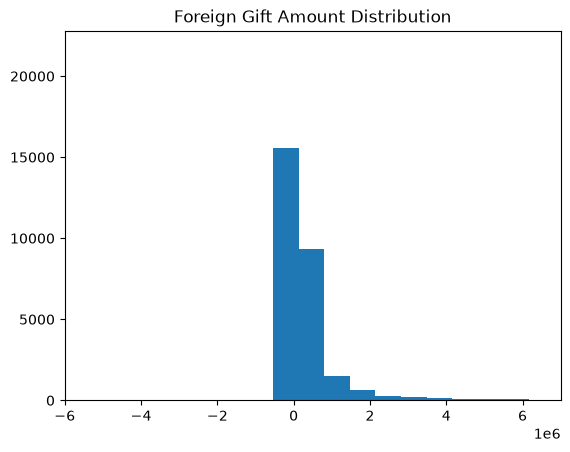

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import seaborn as sns
import numpy as np

foreign = pd.read_csv("C:/Users/charl/Downloads/ForeignGifts_edu.csv")

print(foreign.head)

print(foreign.columns)



frgn_gft_range = [float(foreign["Foreign Gift Amount"].min()), float(foreign["Foreign Gift Amount"].max())]
print(frgn_gft_range)

#Foreign Gift Amount Histogram

gift_amt_hist = foreign["Foreign Gift Amount"].hist(bins=150, grid = False)
gift_amt_hist.set_xlim(-6000000, 7000000)
gift_amt_hist.set_ylim(0,22800)
gift_amt_hist.set_title("Foreign Gift Amount Distribution")


Above, I plotted a histogram of the Foreign Gift Amount variable with 150 bins. The histogram is skewed extremely right. The variable is relatively concentrated into the bins between -500000 and 1500000. There are about 25000 gifts that are between these amounts. The negative values are odd because negative gifts do not make sense. This is either a dirty variable or needs further context to be better explained.

In [ ]:
#Gift Type Value Counts Table

foreign["Gift Type"].value_counts()

# contract_ppt = 17274/28220
# monetary_ppt = 10936/28220
re_ppt = 11/28200
print(re_ppt)


0.0003900709219858156


I decided to make a value counts table of Gift Type because I cocnstructed a histogram in the previous question. From this table, I can conclude that Contracts make up about 61% of the Foreign Gifts, while Monetary Gifts make up about 39%. There is a very insignificant amount of Real Estate gifts that make up 0.04% of the Foreign Gifts.

c:\Users\charl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Foreign Gift Amount', ylabel='Density'>

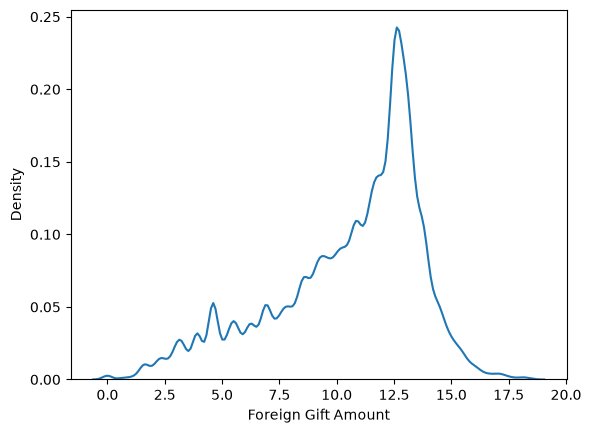

In [ ]:
#KDE of Log of Foreign Gift Amount
log_frgn_gift_amt = np.log(foreign["Foreign Gift Amount"])
sns.kdeplot(log_frgn_gift_amt, bw_adjust=0.5)


<Axes: xlabel='Foreign Gift Amount', ylabel='Density'>

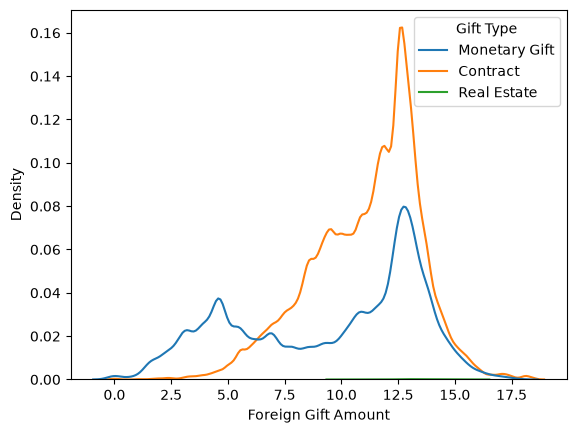

In [ ]:
#KDE of Log of Foreign Gift Amount Conditional on Gift Type
sns.kdeplot(data = foreign, x = log_frgn_gift_amt, hue = "Gift Type", bw_adjust=0.5)


The shape of the uniform kernel density plot is predominantly built on the shape of the kernel density plot of the foreign gift amount by contract gift type. Additionally, the density of the first kernel density plot appears to be the vertical aggregate of the densities of each gift type kde.The detailed variation in the left tail of the first KDE comes from the more variation in the Monetary Gift kde left tail. Finally, the Real Estate gift type did not significantly contribute to the KDE.

In [ ]:
#top 15 countries in terms of gifts
pd.set_option('display.max_rows', None)
count_country_gift = foreign.groupby("Country of Giftor")["Foreign Gift Amount"].count()
count_country_gift.sort_values(ascending=False)

Country of Giftor
ENGLAND                     3655
CHINA                       2461
CANADA                      2344
JAPAN                       1896
SWITZERLAND                 1676
SAUDI ARABIA                1610
FRANCE                      1437
GERMANY                     1394
HONG KONG                   1080
SOUTH KOREA                  811
QATAR                        693
THE NETHERLANDS              512
KOREA                        452
INDIA                        434
TAIWAN                       381
ISRAEL                       373
UNITED ARAB EMIRATES         365
SINGAPORE                    360
AUSTRALIA                    335
ITALY                        318
KUWAIT                       302
DENMARK                      292
SWEDEN                       275
BRAZIL                       256
SPAIN                        240
NORWAY                       240
IRELAND                      224
MEXICO                       221
INDONESIA                    184
NIGERIA                  

I grouped the DataFrame by the "Country of Giftor" and "Foreign Gift Amount" and found that the top 15 countries in terms of number of gifts are: England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan [3.6k, 2.4k, 2.3k, 1.9k, 1.7k, 1.6k, 1.4k, 1.4k, 1k, 811, 693, 512, 452, 434, 381]

In [ ]:
max_country_gift = foreign.groupby("Country of Giftor")["Foreign Gift Amount"].max()
max_country_gift.sort_values(ascending=False)

Country of Giftor
AUSTRALIA                   99999999
QATAR                       99999999
BERMUDA                     75000000
THAILAND                    67700000
CANADA                      48842186
HONG KONG                   47670277
MONACO                      47600000
UNITED ARAB EMIRATES        43021197
SAUDI ARABIA                43000000
SINGAPORE                   40000000
IRAQ                        39108635
INDIA                       38000000
CHINA                       35000000
ENGLAND                     33880638
GERMANY                     33044704
RUSSIA                      30000000
NORWAY                      27275540
RWANDA                      26951170
SPAIN                       25800381
FRANCE                      25458640
JAPAN                       25000000
GREECE                      24477000
PORTUGAL                    23136000
THE NETHERLANDS             21761153
ITALY                       21500000
CHILE                       18500000
DENMARK             

I grouped the DataFrame by the "Country of Giftor" and "Foreign Gift Amount" and found that the top 15 countries in terms of amount given are: Australia, Qatar, Bermuda, Thailand, Canada, Hong Kong, Monaco, UAE, Saudi Arabia, Singapore, Iraq, India, China, England, and Germany: [9.9M, 9.9M, 7.5M, 6.7M, 4.8M, 4.7M, 4.7M, 4.3M, 4.3M, 4M, 3.9M, 3.8M, 3.5M, 3.3M, 3.3M]

In [ ]:
sum_country_gift = foreign.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
sum_country_gift.sort_values(ascending=False)

Country of Giftor
QATAR                       2706240869
ENGLAND                     1464906771
CHINA                       1237952112
SAUDI ARABIA                1065205930
BERMUDA                      899593972
CANADA                       898160656
HONG KONG                    887402529
JAPAN                        655954776
SWITZERLAND                  619899445
INDIA                        539556490
GERMANY                      442475605
UNITED ARAB EMIRATES         431396357
FRANCE                       405839396
SINGAPORE                    401157692
AUSTRALIA                    248409202
KUWAIT                       234106321
DENMARK                      173956102
THE NETHERLANDS              166062836
BRAZIL                       158757039
SWEDEN                       157650306
SOUTH KOREA                  149238934
SPAIN                        144324788
NORWAY                       138481630
THAILAND                     136640519
ISRAEL                       124045080
KOREA  

I grouped the DataFrame by the "Country of Giftor" and "Foreign Gift Amount" and found that the countries Qatar, England, China, and Saudi Arabia gifted the most amounts of money: [2.7T, 1.4T, 1.2T, 1T]

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]